In [10]:
# ── Fed Figure A3 Replication ─────────────────────────────────────────────────
# Scatter: predicted tariff effect vs. excess inflation by PCE category
#
# Excess inflation definition (matching Fed FEDS Note Part II, Apr 2026):
#   Baseline = category-average monthly inflation, Jan 2024 -> Dec 2024
#   Current  = cumulative inflation, Jan 2025 -> Feb 2026 (13 months)
#   Excess   = current - baseline trend (scaled to 13-month horizon)

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import requests

import config
import concordance
import pipeline
importlib.reload(config)
importlib.reload(concordance)
importlib.reload(pipeline)

# ── Run pipeline steps 1-6 ───────────────────────────────────────────────────
import_shares = pipeline.step1_import_shares(config.IO_YEAR, config.BEA_KEY)
industries, A, L = pipeline.step2_3_leontief(
    config.IO_YEAR, config.BEA_KEY, config.LEONTIEF_SOURCE
)
m_vec, m_total = pipeline.step4_total_import_content(import_shares, industries, L)
delta_tariff_df = pipeline.step5_delta_tariff(
    config.IMPORTS_FILE,
    config.TARIFF_BASELINE_YEAR,
    config.TARIFF_CURRENT_MONTH,
    concordance_method=config.CONCORDANCE_METHOD,
    bea_concordance_file=(config.BEA_CONCORDANCE_FILE or None),
    fallback_to_manual_unmapped=config.CONCORDANCE_FALLBACK_TO_MANUAL_UNMAPPED,
)
pce_bridge = pipeline.load_pce_bridge(config.IO_YEAR, config.BEA_KEY)
pce_effect_df = pipeline.step6_pce_effect(
    industries=industries, m_vec=m_vec, L=L,
    delta_tariff_df=delta_tariff_df, pce_bridge=pce_bridge,
    markup=config.MARKUP_ASSUMPTION,
)

core = pce_effect_df.query('PCE_category in @config.CORE_GOODS_CATEGORIES').copy()
core['pce_share'] = core['purchasers_value_total'] / core['purchasers_value_total'].sum()
print(f'Pipeline complete - {len(core)} core goods categories')

Leontief source: BEA pre-computed Total Requirements (TableID 59)
Concordance built (bea_file): 383/388 NAICS6 codes mapped to BEA IO industries
  Manual fallback used for 9 unmapped NAICS6 codes
  Out of scope (services/unmapped): 5 codes
  BEA IO industries covered: 23

Import value coverage: 94.6% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 93.5% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
Pipeline complete - 27 core goods categories


In [11]:
# ── Fetch monthly U20404 price indexes for 2014-2026 ─────────────────────────
# Need: 2014-2019 for baseline, 2023-2026 for Fed window + current

year_str = ','.join(str(y) for y in range(2014, 2027))
print(f'Fetching U20404 for years: {year_str}')

r = requests.get(
    'https://apps.bea.gov/api/data'
    f'?UserID={config.BEA_KEY}'
    '&method=GetData'
    '&DataSetName=NIUnderlyingDetail'
    '&TableName=U20404'
    '&Frequency=M'
    f'&Year={year_str}'
    '&ResultFormat=json'
)
r.raise_for_status()
pce_monthly = pd.DataFrame(r.json()['BEAAPI']['Results']['Data'])
pce_monthly['DataValue'] = pd.to_numeric(pce_monthly['DataValue'], errors='coerce')
pce_monthly['TimePeriod'] = pce_monthly['TimePeriod'].str.replace('M', '-', regex=False)

# Filter to our 27 core goods categories
bea_names = list(config.NIPA_CROSSWALK.values())
pce_monthly = pce_monthly[pce_monthly['LineDescription'].isin(bea_names)]
_price_wide = pce_monthly.pivot(index='LineDescription', columns='TimePeriod', values='DataValue')

print(f'Price data: {_price_wide.shape[0]} categories, {_price_wide.shape[1]} months')
print(f'Date range: {sorted(_price_wide.columns)[0]} - {sorted(_price_wide.columns)[-1]}')

Fetching U20404 for years: 2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Price data: 27 categories, 146 months
Date range: 2014-01 - 2026-02


In [12]:
# ── Excess inflation: Fed Figure A3 definition ───────────────────────────────
#
# Baseline: average monthly inflation rate over Jan 2024 - Dec 2024
#   = mean of { P(2024-m) / P(2024-(m-1)) - 1 } for m = 1..12
#   where m-1 for Jan is Dec 2023
#
# Current: cumulative inflation Jan 2025 -> Feb 2026 (13 months)
#   = P(2026-02) / P(2025-01) - 1
#
# Baseline trend scaled to 13 months:
#   baseline_13mo = (1 + avg_monthly_rate)^13 - 1
#
# Excess = current_13mo - baseline_13mo

# Monthly rates for 2024
months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]

monthly_rates = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates[cur] = _price_wide[cur] / _price_wide[prev] - 1

avg_monthly_rate = monthly_rates.mean(axis=1)
print('Average monthly inflation rate (2024), selected categories:')
print(avg_monthly_rate.head().round(6))

# Baseline trend scaled to 13 months (Jan 2025 -> Feb 2026)
N_MONTHS = 13
baseline_trend = (1 + avg_monthly_rate)**N_MONTHS - 1

# Current period: Jan 2025 -> Feb 2026
current_inflation = _price_wide['2026-02'] / _price_wide['2025-01'] - 1

# Excess
excess_inflation = current_inflation - baseline_trend

# Build results table
nipa_inv = {v: k for k, v in config.NIPA_CROSSWALK.items()}
results = pd.DataFrame({
    'bea_name': excess_inflation.index,
    'PCE_category': [nipa_inv.get(n, n) for n in excess_inflation.index],
    'current_inflation': current_inflation,
    'baseline_trend': baseline_trend,
    'excess_inflation': excess_inflation,
})

# Merge predicted effect and PCE share
results = results.merge(
    core[['PCE_category', 'predicted_effect', 'pce_share']],
    on='PCE_category', how='inner',
)

# Contribution units (pp of core goods PCE)
results['predicted_contrib_pp'] = results['predicted_effect'] * results['pce_share'] * 100
results['excess_contrib_pp'] = results['excess_inflation'] * results['pce_share'] * 100

print(f'\nCategories matched: {len(results)}')
print(f'Total predicted contribution: {results["predicted_contrib_pp"].sum():.2f} pp')
print(f'Total excess contribution:   {results["excess_contrib_pp"].sum():.2f} pp')
print()
results[['PCE_category', 'predicted_effect', 'excess_inflation',
         'predicted_contrib_pp', 'excess_contrib_pp']].round(4)

Average monthly inflation rate (2024), selected categories:
LineDescription
Children's and infants' clothing (12)               -0.000044
Educational books (96)                               0.006731
Furniture and furnishings (parts of 31 and 32)      -0.000859
Glassware, tableware, and household utensils (34)   -0.004353
Household appliances (part of 33)                   -0.003799
dtype: float64

Categories matched: 27
Total predicted contribution: 2.08 pp
Total excess contribution:   2.90 pp



,PCE_category,predicted_effect,excess_inflation,predicted_contrib_pp,excess_contrib_pp
0,Children's and infants' clothing,0.0182,0.0056,0.0110,0.0034
1,Educational books,0.0009,-0.0901,0.0002,-0.0177
2,Furniture and furnishings,0.0289,0.0528,0.1881,0.3436
3,"Glassware, tableware, and household utensils",0.0260,0.1601,0.0356,0.2186
4,Household appliances,0.0395,0.0840,0.0804,0.1710
5,Household supplies,0.0163,0.0215,0.0718,0.0948
6,Jewelry and watches,0.0139,0.1081,0.0337,0.2612
7,Luggage and similar personal items,0.0593,0.0610,0.0658,0.0677
8,"Magazines, newspapers, and stationery",0.0031,0.0550,0.0085,0.1511
9,Men's and boys' clothing,0.0577,-0.0105,0.1921,-0.0351


## Role of Aggregation (comparison document, Section 2)

Fed window scatter at 27 summary categories. Produces `fed_fig_a3_comparison.png`.

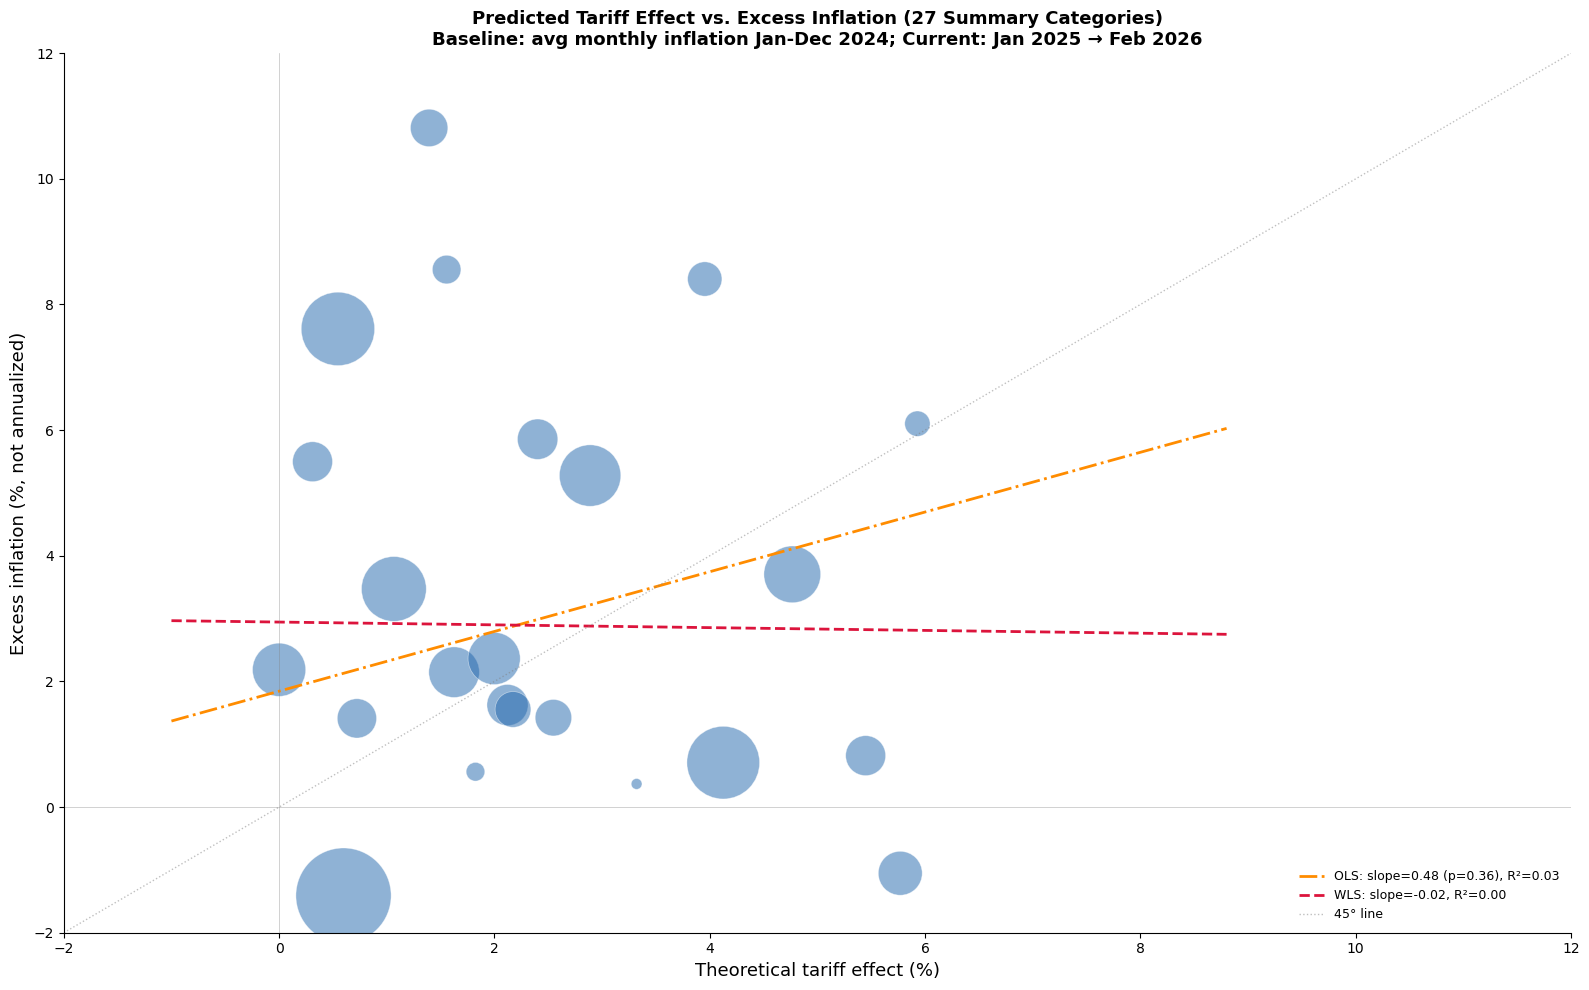


Our OLS:       slope=0.48 (p=0.36), intercept=1.84 (p=0.27), R²=0.029
Our WLS:       slope=-0.02, intercept=2.94, R²=0.000
Fed Figure A3: slope=0.78 (p=0.04), intercept=0.39 (p=0.80)
Saved figures/fed_fig_a3_comparison.png


In [13]:
# ── Scatter: Predicted tariff effect vs. Excess inflation (Fed Fig A3 style) ──
# Matching Fed: unweighted OLS, % units, not annualized

fig, ax = plt.subplots(figsize=(16, 10))

x = results['predicted_effect'] * 100   # theoretical tariff effect (%)
y = results['excess_inflation'] * 100   # excess inflation (%)
sizes = results['pce_share'] * 30000    # bubble size ~ PCE share

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

# Unweighted OLS (matching Fed)
ols = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols, intercept_ols = ols.params.iloc[1], ols.params.iloc[0]
p_slope_ols, p_intercept_ols = ols.pvalues.iloc[1], ols.pvalues.iloc[0]

# WLS (weighted by PCE share)
wls = sm.WLS(y, sm.add_constant(x), weights=results['pce_share']).fit()
slope_wls, intercept_wls = wls.params.iloc[1], wls.params.iloc[0]
p_slope_wls = wls.pvalues.iloc[1]

# Fit lines spanning full axis range
x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols + slope_ols * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols:.2f} (p={p_slope_ols:.2f}), R\u00b2={ols.rsquared:.2f}')
ax.plot(x_grid, intercept_wls + slope_wls * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls:.2f} (p={p_slope_wls:.2f}), R\u00b2={wls.rsquared:.2f}')

# 45-degree line
lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Excess inflation (%, not annualized)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Excess Inflation ({len(results)} Summary Categories)\n'
    'Baseline: avg monthly inflation Jan-Dec 2024; Current: Jan 2025 \u2192 Feb 2026',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOur OLS:       slope={slope_ols:.2f} (p={p_slope_ols:.2f}), '
      f'intercept={intercept_ols:.2f} (p={p_intercept_ols:.2f}), R\u00b2={ols.rsquared:.3f}')
print(f'Our WLS:       slope={slope_wls:.2f}, intercept={intercept_wls:.2f}, R\u00b2={wls.rsquared:.3f}')
print(f'Fed Figure A3: slope=0.78 (p=0.04), intercept=0.39 (p=0.80)')
print('Saved figures/fed_fig_a3_comparison.png')

In [14]:
# ── Summary: our numbers vs. Fed ─────────────────────────────────────────────

print('=' * 72)
print('  Comparison with Fed FEDS Note Part II (Minton/Ray/Somale, Apr 2026)')
print('=' * 72)

print(f'\n  Our predicted core goods PCE effect:  '
      f'{results["predicted_contrib_pp"].sum():.2f} pp')
print(f'  Fed predicted core goods PCE effect: ~3.1 pp (from Part I)')

print(f'\n  Our OLS slope (% units):  {slope_ols:.2f} (p={p_slope_ols:.2f})')
print(f'  Our WLS slope (% units):  {slope_wls:.2f}')
print(f'  Fed slope (Fig A3):       0.78 (p=0.04)')

print(f'\n  Our OLS intercept:        {intercept_ols:.2f} (p={p_intercept_ols:.2f})')
print(f'  Fed intercept:            0.39 (p=0.80)')

print(f'\n  Key methodology differences:')
print(f'    1. IO table: BEA Summary (71 comm.) vs Fed GVC (140 x 8 regions)')
print(f'    2. Tariff rates: Revenue-based vs. statutory/announced rates')
print(f'    3. Leontief: BEA published vs Fed GVC-based')
print(f'    4. Pass-through: One-time level shift vs distributed lag regression')
print(f'\n  Revenue-based tariff rates likely explain most of the level gap:')
print(f'    Our delta-tau are smaller -> lower predicted effects -> lower X-axis values')
print(f'    But the cross-category pattern (slope/R2) should be comparable')

  Comparison with Fed FEDS Note Part II (Minton/Ray/Somale, Apr 2026)

  Our predicted core goods PCE effect:  2.08 pp
  Fed predicted core goods PCE effect: ~3.1 pp (from Part I)

  Our OLS slope (% units):  0.48 (p=0.36)
  Our WLS slope (% units):  -0.02
  Fed slope (Fig A3):       0.78 (p=0.04)

  Our OLS intercept:        1.84 (p=0.27)
  Fed intercept:            0.39 (p=0.80)

  Key methodology differences:
    1. IO table: BEA Summary (71 comm.) vs Fed GVC (140 x 8 regions)
    2. Tariff rates: Revenue-based vs. statutory/announced rates
    3. Leontief: BEA published vs Fed GVC-based
    4. Pass-through: One-time level shift vs distributed lag regression

  Revenue-based tariff rates likely explain most of the level gap:
    Our delta-tau are smaller -> lower predicted effects -> lower X-axis values
    But the cross-category pattern (slope/R2) should be comparable


## Pre-period and Window of Inflation (comparison document, Section 3)

Same side-by-side analysis as the detail notebook, at 27 summary categories.

In [ ]:
# ── Side-by-side: Excess vs Actual inflation, Jan 2025 → Feb 2026 (27 cats) ──
# Left panel:  Excess inflation (Fed 2024 monthly baseline scaled to 13 mo)
# Right panel: Actual inflation (no baseline subtraction)

nipa_inv = {v: k for k, v in config.NIPA_CROSSWALK.items()}

# Fed baseline: avg monthly rate 2024, scaled to 13 months
months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]
monthly_rates_27 = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates_27[cur] = _price_wide[cur] / _price_wide[prev] - 1
avg_monthly_27 = monthly_rates_27.mean(axis=1)
baseline_13_27 = (1 + avg_monthly_27)**13 - 1

# Current: Jan 2025 -> Feb 2026
current_13_27 = _price_wide['2026-02'] / _price_wide['2025-01'] - 1
excess_13_27 = current_13_27 - baseline_13_27

panels = [
    ('Excess inflation (Fed baseline)', excess_13_27, 'Excess inflation (%, 13-month)'),
    ('Actual inflation (no baseline)', current_13_27, 'Actual inflation (%, 13-month)'),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (panel_title, y_series, y_label) in zip(axes, panels):
    res = pd.DataFrame({
        'bea_name': y_series.index,
        'PCE_category': [nipa_inv.get(n, n) for n in y_series.index],
        'y_val': y_series,
    })
    res = res.merge(
        core[['PCE_category', 'predicted_effect', 'pce_share']],
        on='PCE_category', how='inner',
    )

    x = res['predicted_effect'] * 100
    y = res['y_val'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45\u00b0 line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_title(
        f'{panel_title}\n'
        f'Jan 2025 \u2192 Feb 2026 (13 months)  |  OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{panel_title}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_excess_vs_actual.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_excess_vs_actual.png')

In [ ]:
# ── Side-by-side: Excess vs Actual, Dec 2024 → Feb 2026 (27 cats) ──────
# Left panel:  Excess inflation (Fed 2024 monthly baseline scaled to 14 mo)
# Right panel: Actual inflation (no baseline subtraction)

nipa_inv = {v: k for k, v in config.NIPA_CROSSWALK.items()}

# Fed baseline: avg monthly rate 2024, scaled to 14 months
months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]
monthly_rates_27 = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates_27[cur] = _price_wide[cur] / _price_wide[prev] - 1
avg_monthly_27 = monthly_rates_27.mean(axis=1)
baseline_scaled_27 = (1 + avg_monthly_27)**14 - 1

current_27 = _price_wide['2026-02'] / _price_wide['2024-12'] - 1
excess_27 = current_27 - baseline_scaled_27

panels = [
    ('Excess inflation (Fed baseline)', excess_27, 'Excess inflation (%, 14-month)'),
    ('Actual inflation (no baseline)', current_27, 'Actual inflation (%, 14-month)'),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (panel_title, y_series, y_label) in zip(axes, panels):
    res = pd.DataFrame({
        'bea_name': y_series.index,
        'PCE_category': [nipa_inv.get(n, n) for n in y_series.index],
        'y_val': y_series,
    })
    res = res.merge(
        core[['PCE_category', 'predicted_effect', 'pce_share']],
        on='PCE_category', how='inner',
    )

    x = res['predicted_effect'] * 100
    y = res['y_val'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45\u00b0 line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_title(
        f'{panel_title}\n'
        f'Dec 2024 \u2192 Feb 2026 (14 months)  |  OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{panel_title}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_excess_vs_actual_dec24.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_excess_vs_actual_dec24.png')

## Additional Analysis

Supporting figures not directly referenced in the comparison document.

In [ ]:
# ── Excess inflation: Jan 2025 → Feb 2026, baseline 2015-2019 (27 categories) ─
# Current:  P(2026-02) / P(2025-01) - 1  (13 months)
# Baseline: avg Dec-over-Dec growth rate 2015-2019, scaled to 13 months

nipa_inv = {v: k for k, v in config.NIPA_CROSSWALK.items()}

baseline_years = range(2015, 2020)
baseline_rates_27 = pd.DataFrame(index=_price_wide.index)

for yr in baseline_years:
    dec_cur = f'{yr}-12'
    dec_prev = f'{yr-1}-12'
    if dec_cur in _price_wide.columns and dec_prev in _price_wide.columns:
        baseline_rates_27[yr] = _price_wide[dec_cur] / _price_wide[dec_prev] - 1
    else:
        print(f'  WARNING: missing {dec_prev} or {dec_cur}')

baseline_avg_27 = baseline_rates_27.mean(axis=1)

# Scale annual baseline to 13 months
N_MONTHS_REPO = 13
baseline_scaled_13_27 = (1 + baseline_avg_27)**(N_MONTHS_REPO / 12) - 1

# Current period: Jan 2025 -> Feb 2026 (13 months)
current_inf_repo_27 = _price_wide['2026-02'] / _price_wide['2025-01'] - 1
excess_inf_repo_27 = current_inf_repo_27 - baseline_scaled_13_27

# Build results table
results_repo_27 = pd.DataFrame({
    'bea_name': excess_inf_repo_27.index,
    'PCE_category': [nipa_inv.get(n, n) for n in excess_inf_repo_27.index],
    'current_inflation': current_inf_repo_27,
    'baseline_avg': baseline_avg_27,
    'baseline_scaled_13mo': baseline_scaled_13_27,
    'excess_inflation': excess_inf_repo_27,
})
results_repo_27 = results_repo_27.merge(
    core[['PCE_category', 'predicted_effect', 'pce_share']],
    on='PCE_category', how='inner',
)

print(f'Categories matched: {len(results_repo_27)}')
print(f'Median baseline (annual): {baseline_avg_27.median():.2%}')
print(f'Median baseline (13-mo scaled): {baseline_scaled_13_27.median():.2%}')
print(f'Median excess inflation: {excess_inf_repo_27.median():.2%}')

################################################################
fig, ax = plt.subplots(figsize=(16, 10))

x = results_repo_27['predicted_effect'] * 100
y = results_repo_27['excess_inflation'] * 100
sizes = results_repo_27['pce_share'] * 30000

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

ols_r27 = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols_r27, intercept_ols_r27 = ols_r27.params.iloc[1], ols_r27.params.iloc[0]
p_slope_ols_r27 = ols_r27.pvalues.iloc[1]

wls_r27 = sm.WLS(y, sm.add_constant(x), weights=results_repo_27['pce_share']).fit()
slope_wls_r27, intercept_wls_r27 = wls_r27.params.iloc[1], wls_r27.params.iloc[0]
p_slope_wls_r27 = wls_r27.pvalues.iloc[1]

x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols_r27 + slope_ols_r27 * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols_r27:.2f} (p={p_slope_ols_r27:.2f}), '
              f'R\u00b2={ols_r27.rsquared:.2f}')
ax.plot(x_grid, intercept_wls_r27 + slope_wls_r27 * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls_r27:.2f} (p={p_slope_wls_r27:.2f}), R\u00b2={wls_r27.rsquared:.2f}')

lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Excess inflation (%, 13-month)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Excess Inflation ({len(results_repo_27)} Summary Categories)\n'
    'Current: Jan 2025 \u2192 Feb 2026; Baseline: avg 2015\u20132019 scaled to 13 months',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_repo_window.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOLS: slope={slope_ols_r27:.2f} (p={p_slope_ols_r27:.2f}), '
      f'intercept={intercept_ols_r27:.2f}, R\u00b2={ols_r27.rsquared:.3f}')
print(f'WLS: slope={slope_wls_r27:.2f} (p={p_slope_wls_r27:.2f}), intercept={intercept_wls_r27:.2f}, '
      f'R\u00b2={wls_r27.rsquared:.3f}')
print('Saved figures/fed_fig_a3_repo_window.png')

Categories matched: 27
Median excess inflation (14mo): 3.52%


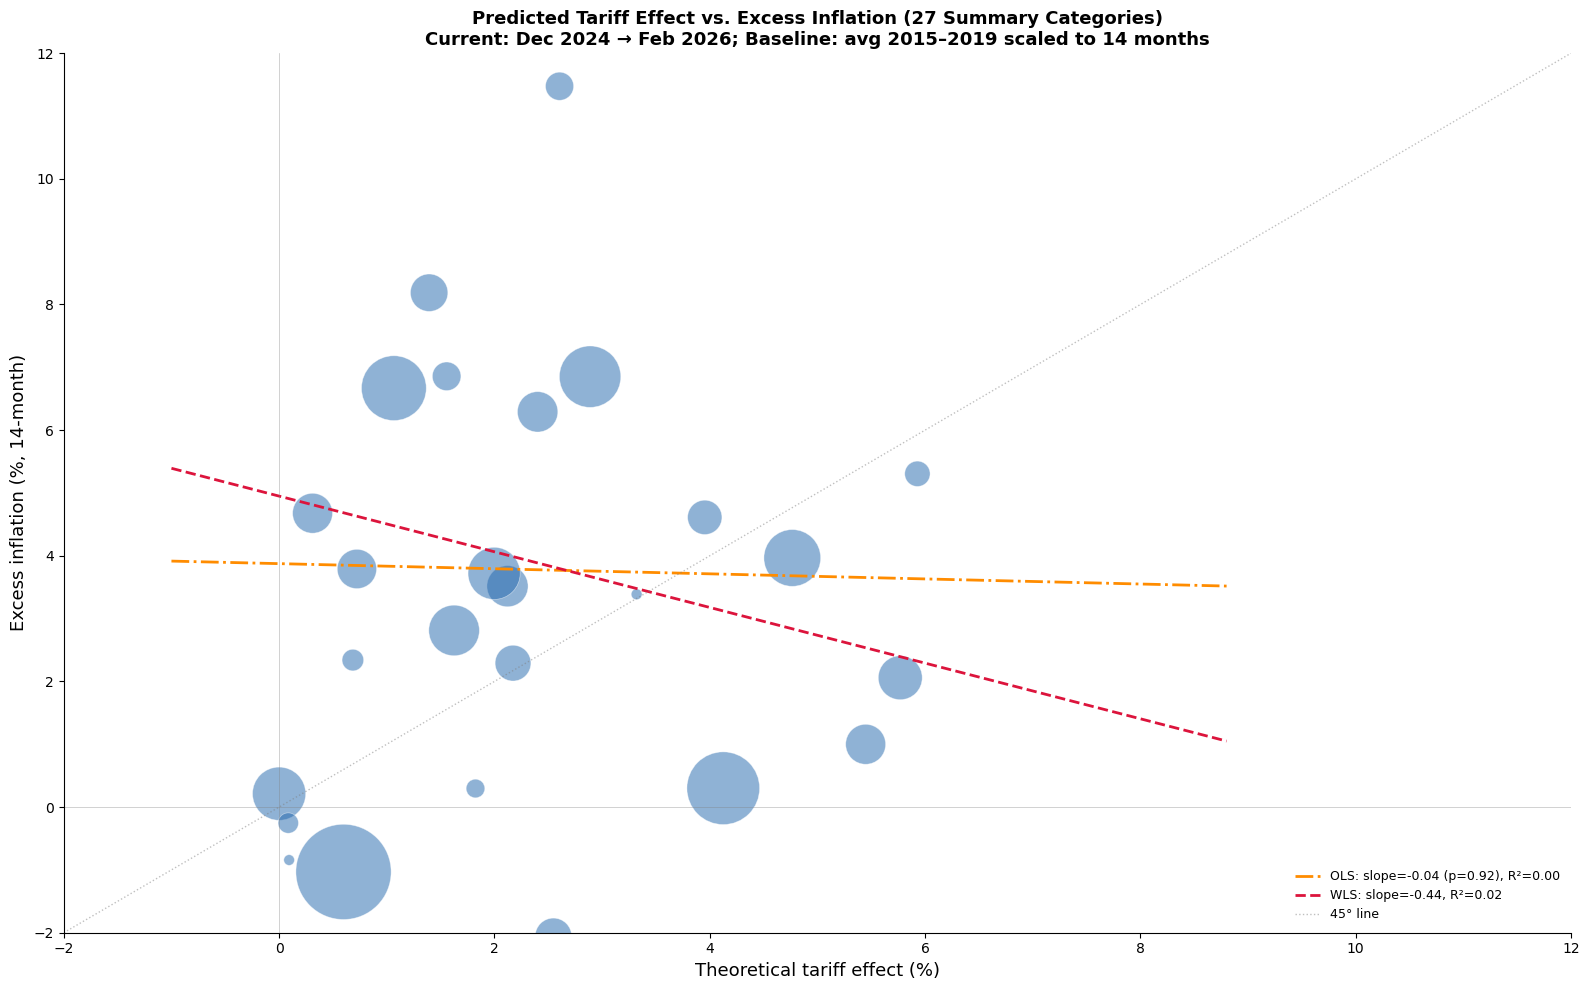


OLS: slope=-0.04 (p=0.92), intercept=3.87, R²=0.000
WLS: slope=-0.44, intercept=4.95, R²=0.025
Saved figures/fed_fig_a3_extended.png


In [16]:
# ── Excess inflation: Dec 2024 → Feb 2026, baseline 2015-2019 (27 categories) ─
# Current:  P(2026-02) / P(2024-12) - 1   (14 months)
# Baseline: avg annual Dec-over-Dec rate (2015-2019), scaled to 14 months
#   baseline_14mo = (1 + annual_rate)^(14/12) - 1

N_MONTHS_EXT = 14
baseline_scaled_14_27 = (1 + baseline_avg_27)**(N_MONTHS_EXT / 12) - 1

current_inf_ext_27 = _price_wide['2026-02'] / _price_wide['2024-12'] - 1
excess_inf_ext_27 = current_inf_ext_27 - baseline_scaled_14_27

results_ext_27 = pd.DataFrame({
    'bea_name': excess_inf_ext_27.index,
    'PCE_category': [nipa_inv.get(n, n) for n in excess_inf_ext_27.index],
    'current_inflation': current_inf_ext_27,
    'baseline_scaled': baseline_scaled_14_27,
    'excess_inflation': excess_inf_ext_27,
})
results_ext_27 = results_ext_27.merge(
    core[['PCE_category', 'predicted_effect', 'pce_share']],
    on='PCE_category', how='inner',
)

print(f'Categories matched: {len(results_ext_27)}')
print(f'Median excess inflation (14mo): {excess_inf_ext_27.median():.2%}')

# ── Scatter ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

x = results_ext_27['predicted_effect'] * 100
y = results_ext_27['excess_inflation'] * 100
sizes = results_ext_27['pce_share'] * 30000

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

ols_e27 = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols_e27, intercept_ols_e27 = ols_e27.params.iloc[1], ols_e27.params.iloc[0]
p_slope_ols_e27 = ols_e27.pvalues.iloc[1]

wls_e27 = sm.WLS(y, sm.add_constant(x), weights=results_ext_27['pce_share']).fit()
slope_wls_e27, intercept_wls_e27 = wls_e27.params.iloc[1], wls_e27.params.iloc[0]
p_slope_wls_e27 = wls_e27.pvalues.iloc[1]

x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols_e27 + slope_ols_e27 * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols_e27:.2f} (p={p_slope_ols_e27:.2f}), '
              f'R\u00b2={ols_e27.rsquared:.2f}')
ax.plot(x_grid, intercept_wls_e27 + slope_wls_e27 * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls_e27:.2f} (p={p_slope_wls_e27:.2f}), R\u00b2={wls_e27.rsquared:.2f}')

lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Excess inflation (%, 14-month)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Excess Inflation ({len(results_ext_27)} Summary Categories)\n'
    'Current: Dec 2024 \u2192 Feb 2026; Baseline: avg 2015\u20132019 scaled to 14 months',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_extended.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOLS: slope={slope_ols_e27:.2f} (p={p_slope_ols_e27:.2f}), '
      f'intercept={intercept_ols_e27:.2f}, R\u00b2={ols_e27.rsquared:.3f}')
print(f'WLS: slope={slope_wls_e27:.2f} (p={p_slope_wls_e27:.2f}), intercept={intercept_wls_e27:.2f}, '
      f'R\u00b2={wls_e27.rsquared:.3f}')
print('Saved figures/fed_fig_a3_extended.png')

Categories matched: 27
Median actual inflation: 3.23%


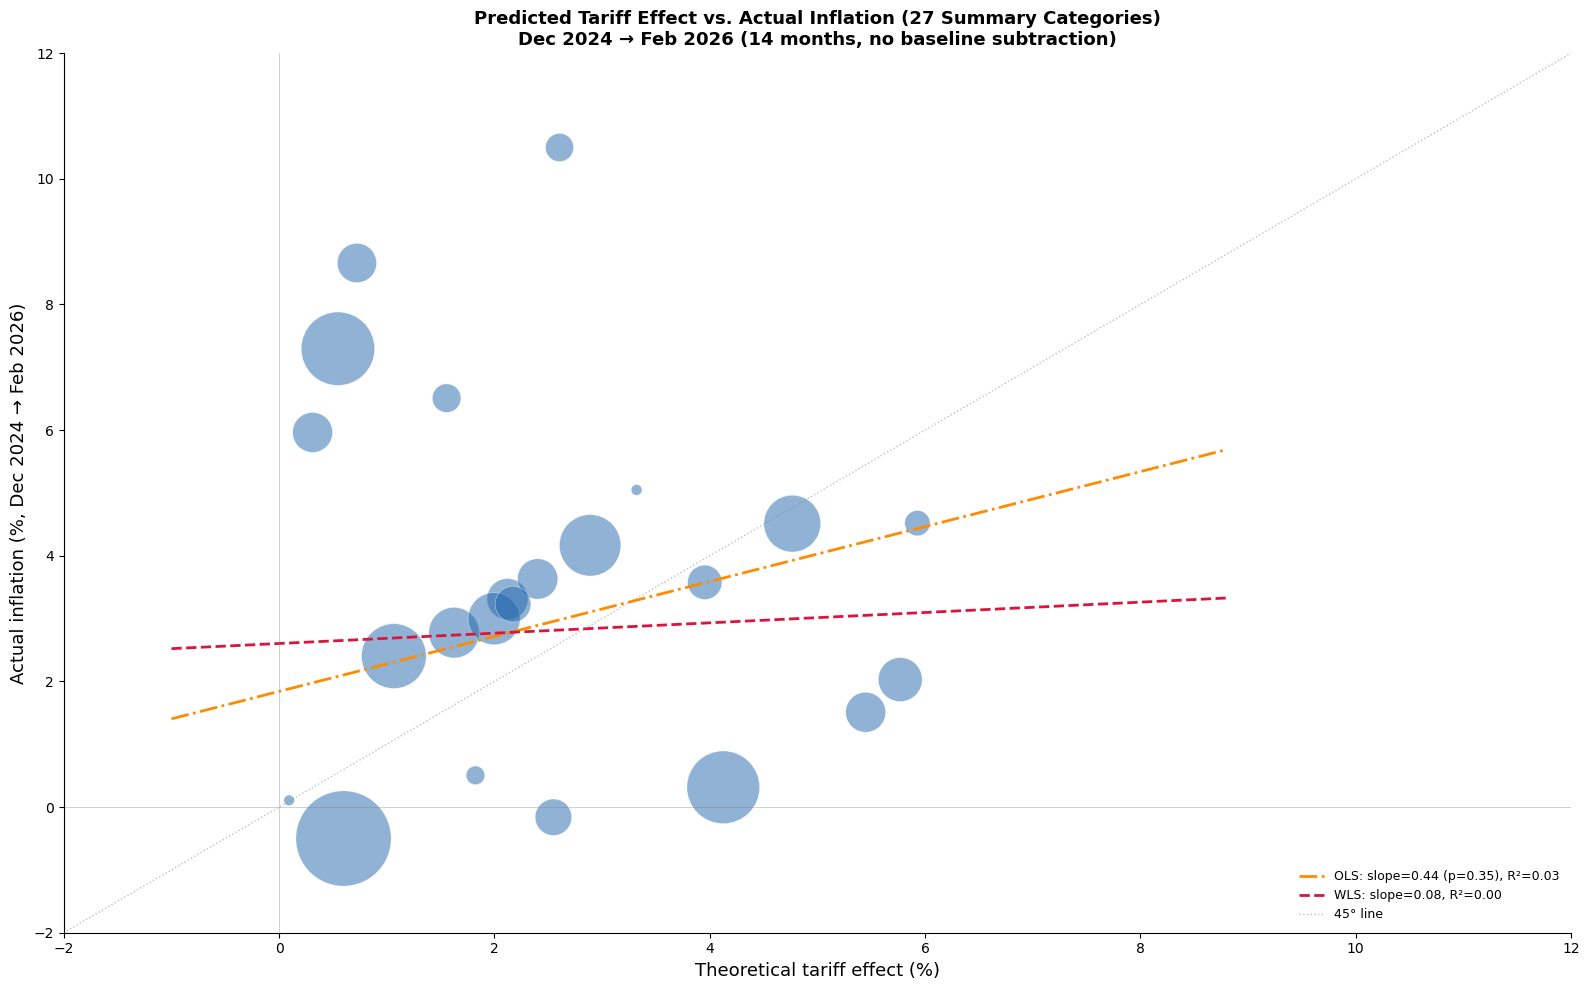


OLS: slope=0.44 (p=0.35), intercept=1.84, R²=0.025
WLS: slope=0.08, intercept=2.60, R²=0.001
Saved figures/fed_fig_a3_actual_inflation.png


In [17]:
# ── Actual inflation: Dec 2024 → Feb 2026 (27 categories, no baseline) ───────
# Y = P(2026-02) / P(2024-12) - 1

actual_inf_27 = _price_wide['2026-02'] / _price_wide['2025-01'] - 1

results_actual_27 = pd.DataFrame({
    'bea_name': actual_inf_27.index,
    'PCE_category': [nipa_inv.get(n, n) for n in actual_inf_27.index],
    'actual_inflation': actual_inf_27,
})
results_actual_27 = results_actual_27.merge(
    core[['PCE_category', 'predicted_effect', 'pce_share']],
    on='PCE_category', how='inner',
)

print(f'Categories matched: {len(results_actual_27)}')
print(f'Median actual inflation: {actual_inf_27.median():.2%}')

# ── Scatter ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

x = results_actual_27['predicted_effect'] * 100
y = results_actual_27['actual_inflation'] * 100
sizes = results_actual_27['pce_share'] * 30000

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

ols_a27 = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols_a27, intercept_ols_a27 = ols_a27.params.iloc[1], ols_a27.params.iloc[0]
p_slope_ols_a27 = ols_a27.pvalues.iloc[1]

wls_a27 = sm.WLS(y, sm.add_constant(x), weights=results_actual_27['pce_share']).fit()
slope_wls_a27, intercept_wls_a27 = wls_a27.params.iloc[1], wls_a27.params.iloc[0]
p_slope_wls_a27 = wls_a27.pvalues.iloc[1]

x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols_a27 + slope_ols_a27 * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols_a27:.2f} (p={p_slope_ols_a27:.2f}), '
              f'R\u00b2={ols_a27.rsquared:.2f}')
ax.plot(x_grid, intercept_wls_a27 + slope_wls_a27 * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls_a27:.2f} (p={p_slope_wls_a27:.2f}), R\u00b2={wls_a27.rsquared:.2f}')

lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Actual inflation (%, Dec 2024 \u2192 Feb 2026)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Actual Inflation ({len(results_actual_27)} Summary Categories)\n'
    'Dec 2024 \u2192 Feb 2026 (14 months, no baseline subtraction)',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_actual_inflation.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOLS: slope={slope_ols_a27:.2f} (p={p_slope_ols_a27:.2f}), '
      f'intercept={intercept_ols_a27:.2f}, R\u00b2={ols_a27.rsquared:.3f}')
print(f'WLS: slope={slope_wls_a27:.2f} (p={p_slope_wls_a27:.2f}), intercept={intercept_wls_a27:.2f}, '
      f'R\u00b2={wls_a27.rsquared:.3f}')
print('Saved figures/fed_fig_a3_actual_inflation.png')

In [18]:
# ── Start-month sensitivity: Dec 2024 vs Jan 2025 (27 categories) ────────────
# Same endpoint (Feb 2026), same baseline (Fed's 2024 monthly avg)
# Only difference: denominator is P(start_month) and baseline scaled accordingly

print('Start-month sensitivity test (Fed baseline, endpoint Feb 2026)')
print('=' * 65)

x_pred = core.set_index('PCE_category')['predicted_effect']

# Map _price_wide index (LineDescription) to PCE_category
price_mapped = _price_wide.copy()
price_mapped.index = [nipa_inv.get(n, n) for n in price_mapped.index]

# Map avg_monthly_rate index the same way
avg_monthly_mapped = avg_monthly_rate.copy()
avg_monthly_mapped.index = [nipa_inv.get(n, n) for n in avg_monthly_mapped.index]

for start_label, start_month, n_months in [
    ('Dec 2024', '2024-12', 14),
    ('Jan 2025', '2025-01', 13),
    ('Feb 2025', '2025-02', 12),
    ('Mar 2025', '2025-03', 11),
]:
    current = price_mapped['2026-02'] / price_mapped[start_month] - 1
    baseline_scaled = (1 + avg_monthly_mapped)**n_months - 1
    excess = current - baseline_scaled

    merged = pd.DataFrame({
        'predicted_effect': x_pred,
        'excess_inflation': excess,
    }).dropna()

    x = merged['predicted_effect'] * 100
    y = merged['excess_inflation'] * 100

    ols_test = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    s = ols_test.params.iloc[1]
    p = ols_test.pvalues.iloc[1]
    r2 = ols_test.rsquared
    icpt = ols_test.params.iloc[0]

    print(f'  Start={start_label} ({n_months}mo):  '
          f'slope={s:.3f} (p={p:.3f}), intercept={icpt:.2f}, R\u00b2={r2:.4f}')

print(f'\n  Fed reported:           slope=0.780 (p=0.040)')
print(f'\n  Note: Jan 2025 is 1 month into the tariff regime.')
print(f'  Dec 2024 includes 1 month of pre-tariff price movement,')
print(f'  which adds noise uncorrelated with tariff predictions.')

Start-month sensitivity test (Fed baseline, endpoint Feb 2026)
  Start=Dec 2024 (14mo):  slope=0.079 (p=0.874), intercept=2.73, R²=0.0010
  Start=Jan 2025 (13mo):  slope=0.475 (p=0.358), intercept=1.84, R²=0.0295
  Start=Feb 2025 (12mo):  slope=0.456 (p=0.324), intercept=1.60, R²=0.0334
  Start=Mar 2025 (11mo):  slope=0.500 (p=0.300), intercept=1.43, R²=0.0383

  Fed reported:           slope=0.780 (p=0.040)

  Note: Jan 2025 is 1 month into the tariff regime.
  Dec 2024 includes 1 month of pre-tariff price movement,
  which adds noise uncorrelated with tariff predictions.


In [ ]:
# ── Side-by-side: Actual inflation Dec 2024 vs Jan 2025 start (27 categories) ─
# Left panel:  P(2026-02) / P(2024-12) - 1  (14 months)
# Right panel: P(2026-02) / P(2025-01) - 1  (13 months)

nipa_inv = {v: k for k, v in config.NIPA_CROSSWALK.items()}

panels = [
    ('Dec 2024', '2024-12', 14),
    ('Jan 2025', '2025-01', 13),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (start_label, start_month, n_months) in zip(axes, panels):
    actual_inf = _price_wide['2026-02'] / _price_wide[start_month] - 1

    res = pd.DataFrame({
        'bea_name': actual_inf.index,
        'PCE_category': [nipa_inv.get(n, n) for n in actual_inf.index],
        'actual_inflation': actual_inf,
    })
    res = res.merge(
        core[['PCE_category', 'predicted_effect', 'pce_share']],
        on='PCE_category', how='inner',
    )

    x = res['predicted_effect'] * 100
    y = res['actual_inflation'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R²={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R²={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45° line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(f'Actual inflation (%, {start_label} → Feb 2026)', fontsize=16)
    ax.set_title(
        f'{start_label} → Feb 2026 ({n_months} months)\n'
        f'OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{start_label}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R²={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R²={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_start_month_sidebyside.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_start_month_sidebyside.png')

In [ ]:
# ── Side-by-side: Excess vs Actual, Apr 2025 → Feb 2026 (27 cats) ──────
# Left panel:  Excess inflation (Fed 2024 monthly baseline scaled to 10 mo)
# Right panel: Actual inflation (no baseline subtraction)

nipa_inv = {v: k for k, v in config.NIPA_CROSSWALK.items()}

# Fed baseline: avg monthly rate 2024, scaled to 10 months
months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]
monthly_rates_27 = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates_27[cur] = _price_wide[cur] / _price_wide[prev] - 1
avg_monthly_27 = monthly_rates_27.mean(axis=1)
baseline_scaled_27 = (1 + avg_monthly_27)**10 - 1

current_27 = _price_wide['2026-02'] / _price_wide['2025-04'] - 1
excess_27 = current_27 - baseline_scaled_27

panels = [
    ('Excess inflation (Fed baseline)', excess_27, 'Excess inflation (%, 10-month)'),
    ('Actual inflation (no baseline)', current_27, 'Actual inflation (%, 10-month)'),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (panel_title, y_series, y_label) in zip(axes, panels):
    res = pd.DataFrame({
        'bea_name': y_series.index,
        'PCE_category': [nipa_inv.get(n, n) for n in y_series.index],
        'y_val': y_series,
    })
    res = res.merge(
        core[['PCE_category', 'predicted_effect', 'pce_share']],
        on='PCE_category', how='inner',
    )

    x = res['predicted_effect'] * 100
    y = res['y_val'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45\u00b0 line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_title(
        f'{panel_title}\n'
        f'Apr 2025 \u2192 Feb 2026 (10 months)  |  OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{panel_title}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_excess_vs_actual_apr25.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_excess_vs_actual_apr25.png')